<a href="https://colab.research.google.com/github/Ersaoktaviannn/eeg-creative-state-classifier/blob/dev/EEG_Primary_Secondary_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Sel instalasi dependensi
%pip -q install "decorator>=4.0.2,<5.0" "mne==1.6.1" "jedi>=0.16" "PyWavelets>=1.4" "h5py>=3.8" "joblib>=1.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 136.2 MB/s eta 0:00:00


In [1]:
# ============================================================
# REMOUNT GOOGLE DRIVE AGAR SHORTCUT BARU TERBACA
# ============================================================

from google.colab import drive
from pathlib import Path
import os

try:
    drive.flush_and_unmount()
    print("Drive lama berhasil di-unmount.")
except Exception as e:
    print("Drive belum termount atau gagal unmount:", e)

drive.mount("/content/drive", force_remount=True)

print("Remount selesai.")
print("Cek MyDrive:")
print(os.listdir("/content/drive/MyDrive")[:20])

Drive not mounted, so nothing to flush and unmount.
Drive lama berhasil di-unmount.
Mounted at /content/drive
Remount selesai.
Cek MyDrive:
['Colab Notebooks', 'skripsi-zaky', 'skripsi-rezky', 'skripsi-rofid', 'skripsi-thoriq', 'skripsi-anas', 'Creativity-Dataset']


In [2]:
from pathlib import Path
import os

DRIVE_BASE = Path("/content/drive/MyDrive/Creativity-Dataset")

print("DRIVE_BASE:", DRIVE_BASE)
print("exists:", DRIVE_BASE.exists())
print("is_dir:", DRIVE_BASE.is_dir())

if DRIVE_BASE.exists():
    print("\nIsi folder Creativity-Dataset:")
    for item in DRIVE_BASE.iterdir():
        print("-", item.name, "| dir:", item.is_dir())

print("\nCek jumlah file .mat:")
for folder_name in ["Secondary", "Primary-raw", "Primary-merged"]:
    p = DRIVE_BASE / folder_name
    n_mat = len(list(p.rglob("*.mat"))) if p.exists() else 0
    print(folder_name, "| exists:", p.exists(), "| .mat:", n_mat)

print("\nTotal .mat semua subfolder:")
print(len(list(DRIVE_BASE.rglob("*.mat"))) if DRIVE_BASE.exists() else 0)

DRIVE_BASE: /content/drive/MyDrive/Creativity-Dataset
exists: True
is_dir: True

Isi folder Creativity-Dataset:
- Secondary | dir: True
- ADD | dir: True
- Primary-merged | dir: True
- Primary-raw | dir: True
- cache | dir: True
- output | dir: True

Cek jumlah file .mat:
Secondary | exists: True | .mat: 28
Primary-raw | exists: True | .mat: 33
Primary-merged | exists: True | .mat: 5

Total .mat semua subfolder:
66


In [3]:
# ============================================================
# SYNC DATASET DARI DRIVE SHORTCUT KE LOCAL RUNTIME
# ============================================================

from pathlib import Path
import shutil

DRIVE_BASE = Path("/content/drive/MyDrive/Creativity-Dataset")
LOCAL_BASE = Path("/content/Creativity-Dataset")

FORCE_SYNC_LOCAL = True

if not DRIVE_BASE.exists():
    raise FileNotFoundError(f"Folder tidak ditemukan: {DRIVE_BASE}")

total_mat = len(list(DRIVE_BASE.rglob("*.mat")))

if total_mat == 0:
    raise ValueError(
        "Folder Creativity-Dataset terbaca, tetapi file .mat masih 0. "
        "Kemungkinan shortcut belum terbaca, isi folder bukan dataset utama, atau akses folder belum full."
    )

print("Total .mat di Drive:", total_mat)

LOCAL_BASE.mkdir(parents=True, exist_ok=True)

for folder_name in ["Secondary", "Primary-raw", "Primary-merged"]:
    src = DRIVE_BASE / folder_name
    dst = LOCAL_BASE / folder_name

    if not src.exists():
        print("SKIP folder tidak ada:", src)
        continue

    if dst.exists() and FORCE_SYNC_LOCAL:
        shutil.rmtree(dst)

    print(f"Copy {src} -> {dst}")
    shutil.copytree(src, dst)

# Copy CSV jika ada
src_csv = DRIVE_BASE / "primary_segments.csv"
dst_csv = LOCAL_BASE / "primary_segments.csv"

if src_csv.exists():
    shutil.copy2(src_csv, dst_csv)
    print("primary_segments.csv copied")
else:
    print("primary_segments.csv tidak ditemukan, skip.")

# Buat cache dan output lokal
(LOCAL_BASE / "cache").mkdir(parents=True, exist_ok=True)
(LOCAL_BASE / "output").mkdir(parents=True, exist_ok=True)

print("\nCek hasil sync local:")
for folder_name in ["Secondary", "Primary-raw", "Primary-merged"]:
    p = LOCAL_BASE / folder_name
    print(folder_name, "| exists:", p.exists(), "| .mat:", len(list(p.rglob("*.mat"))) if p.exists() else 0)

print("\nTotal .mat local:", len(list(LOCAL_BASE.rglob("*.mat"))))
print("Sync selesai.")

Total .mat di Drive: 66
Copy /content/drive/MyDrive/Creativity-Dataset/Secondary -> /content/Creativity-Dataset/Secondary
Copy /content/drive/MyDrive/Creativity-Dataset/Primary-raw -> /content/Creativity-Dataset/Primary-raw
Copy /content/drive/MyDrive/Creativity-Dataset/Primary-merged -> /content/Creativity-Dataset/Primary-merged
primary_segments.csv tidak ditemukan, skip.

Cek hasil sync local:
Secondary | exists: True | .mat: 28
Primary-raw | exists: True | .mat: 33
Primary-merged | exists: True | .mat: 5

Total .mat local: 66
Sync selesai.


In [5]:
# ============================================================
# CELL 1 — KONFIGURASI & IMPORT
# ============================================================

from google.colab import drive
from pathlib import Path

import json
import re
import warnings
import h5py
import joblib
import mne
import pywt
import decorator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import ipywidgets as widgets

from math import gcd
from hashlib import sha1
from IPython.display import display, clear_output

from scipy.signal import (
    butter,
    detrend,
    resample_poly,
    sosfiltfilt,
    welch,
)

from scipy.stats import entropy

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)

from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    LeaveOneGroupOut,
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler


if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")


# ============================================================
# PATH DATASET
# ============================================================
BASE_DIR = Path("/content/Creativity-Dataset/")

SECONDARY_DIR = BASE_DIR / "Secondary"
PRIMARY_RAW_DIR = BASE_DIR / "Primary-raw"
PRIMARY_MERGED_DIR = BASE_DIR / "Primary-merged"

PRIMARY_SEGMENTS_CSV = BASE_DIR / "primary_segments.csv"

CACHE_DIR = BASE_DIR / "cache"
PREPROCESSED_CACHE_DIR = CACHE_DIR / "preprocessed"
FEATURE_CACHE_DIR = CACHE_DIR / "features"
OUTPUT_DIR = BASE_DIR / "output"


for folder in [
    SECONDARY_DIR,
    PRIMARY_RAW_DIR,
    PRIMARY_MERGED_DIR,
]:
    if not folder.exists():
        print("WARNING folder data tidak ditemukan:", folder)

for folder in [
    PREPROCESSED_CACHE_DIR,
    FEATURE_CACHE_DIR,
    OUTPUT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)


# ============================================================
# SIGNAL CONFIG
# ============================================================

FS_PRIMARY = 125
FS_SECONDARY = 500
FS_TARGET = 125

BANDPASS_LOW = 1.0
BANDPASS_HIGH = 40.0
FILTER_ORDER = 4

KNOWN_RAIL_ABS_THRESHOLD = 180000.0
ROBUST_OUTLIER_MAD_MULTIPLIER = 25.0

MAX_REPAIR_RATIO_PER_CHANNEL = 0.05
BAD_CHANNEL_Z_THRESHOLD = 5.0
EPOCH_ARTIFACT_Z_THRESHOLD = 5.0

WAVELET = "db4"
DWT_LEVEL = 5

ADD_SPECTRAL_FEATURES = True


# ============================================================
# CONFIG MERGED 4 KELAS
# ============================================================

MAX_EPOCHS_PER_SUBJECT_CLASS = 300
DEBUG_MAX_SUBJECTS = 9999

# Run pertama True.
# Setelah berhasil dan ingin run ulang lebih cepat, boleh ubah ke False.
FORCE_REBUILD_FEATURES = True

CACHE_VERSION = "v4_merged_4class_fullsubjects"

RANDOM_STATE = 42


# ============================================================
# EXPERIMENT CONFIG
# ============================================================

EXPERIMENT_CONFIGS = [
    {
        "epoch_seconds": 2.0,
        "overlap_ratio": 0.75,
        "primary_trim_seconds": 2.0,
    },
    {
        "epoch_seconds": 2.0,
        "overlap_ratio": 0.50,
        "primary_trim_seconds": 2.0,
    },
    {
        "epoch_seconds": 4.0,
        "overlap_ratio": 0.50,
        "primary_trim_seconds": 2.0,
    },
    {
        "epoch_seconds": 4.0,
        "overlap_ratio": 0.25,
        "primary_trim_seconds": 2.0,
    },
]


# ============================================================
# DATASET MODE
# ============================================================

# Untuk notebook lama gunakan combined.
# Di full patch nanti akan dioverride menjadi merged.
DATASET_MODE = "combined"


# ============================================================
# PRIMARY INPUT MODE
# ============================================================

# "separate" jika data primary masih per folder aktivitas
# "merged" jika data primary sudah .mat per subject
PRIMARY_INPUT_MODE = "separate"


# ============================================================
# FILE SELECTION
# ============================================================

MANUAL_SELECTED_FILES = []

def count_mat_files(path):
    if not path.exists():
        return 0
    return len(list(path.rglob("*.mat")))


print("Environment Ready")
print("BASE_DIR                 :", BASE_DIR)
print("DATASET_MODE             :", DATASET_MODE)
print("PRIMARY_INPUT_MODE       :", PRIMARY_INPUT_MODE)
print("DEBUG_MAX_SUBJECTS       :", DEBUG_MAX_SUBJECTS)
print("FORCE_REBUILD_FEATURES   :", FORCE_REBUILD_FEATURES)
print("CACHE_VERSION            :", CACHE_VERSION)

print("\nJumlah file .mat:")
print("Secondary      :", count_mat_files(SECONDARY_DIR))
print("Primary-raw    :", count_mat_files(PRIMARY_RAW_DIR))
print("Primary-merged :", count_mat_files(PRIMARY_MERGED_DIR))

Environment Ready
BASE_DIR                 : /content/Creativity-Dataset
DATASET_MODE             : combined
PRIMARY_INPUT_MODE       : separate
DEBUG_MAX_SUBJECTS       : 9999
FORCE_REBUILD_FEATURES   : True
CACHE_VERSION            : v4_merged_4class_fullsubjects

Jumlah file .mat:
Secondary      : 28
Primary-raw    : 33
Primary-merged : 5


In [6]:
# ============================================================
# LABEL & KANAL
# ============================================================

LABELS = ["RST1", "IDG", "IDE", "IDR", "RST2"]
PRIMARY_CHANNELS_ORIGINAL = ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "C3", "C4", "T3", "T4", "T5", "T6", "P3", "P4", "O1", "O2"]
CANONICAL_CHANNELS = ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "C3", "C4", "T7", "T8", "P7", "P8", "P3", "P4", "O1", "O2"]

SECONDARY_CHANNELS_64 = [
    "Fp1", "Fp2", "Fpz", "AF3", "AF4", "AF7", "AF8", "AFz", "F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "Fz",
    "FT7", "FT8", "FC1", "FC2", "FC3", "FC4", "FC5", "FC6", "FCz", "T7", "T8", "C1", "C2", "C3", "C4", "C5", "C6", "Cz",
    "TP7", "TP8", "CP1", "CP2", "CP3", "CP4", "CP5", "CP6", "CPz", "P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8",
    "P9", "P10", "Pz", "PO3", "PO4", "PO7", "PO8", "POz", "O1", "O2", "Oz", "Iz"
]

SECONDARY_CHANNELS_63 = [ch for ch in SECONDARY_CHANNELS_64 if ch != "Cz"]
SECONDARY_SELECTED_INDICES = [SECONDARY_CHANNELS_63.index(ch) for ch in CANONICAL_CHANNELS]

def normalize_label(text):
    text = str(text).upper()
    for label in LABELS:
        if label in text: return label
    return None

def infer_subject_id(text, prefix):
    match = re.search(r"SUB(?:JECT)?[_\-\s]*(\d+)", str(text), flags=re.IGNORECASE)
    if not match: raise ValueError(f"Nomor subjek tidak ditemukan: {text}")
    return f"{prefix}_{int(match.group(1)):03d}"

def stable_name(text):
    return sha1(str(text).encode("utf-8")).hexdigest()[:16]

channel_mapping_df = pd.DataFrame({"kanal_primer": PRIMARY_CHANNELS_ORIGINAL, "kanal_harmonisasi": CANONICAL_CHANNELS, "idx_sekunder": SECONDARY_SELECTED_INDICES})
display(channel_mapping_df)
print("Index 16 kanal sekunder:", SECONDARY_SELECTED_INDICES)

,kanal_primer,kanal_harmonisasi,idx_sekunder
0,Fp1,Fp1,0
1,Fp2,Fp2,1
2,F3,F3,10
3,F4,F4,11
4,F7,F7,14
5,F8,F8,15
6,C3,C3,30
7,C4,C4,31
8,T3,T7,26
9,T4,T8,27


Index 16 kanal sekunder: [0, 1, 10, 11, 14, 15, 30, 31, 26, 27, 49, 50, 45, 46, 59, 60]


In [7]:
import re
from pathlib import Path
import scipy.io as sio
import h5py
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from hashlib import sha1

# --- HELPER FUNCTIONS ---
def load_record_eeg(ref):
    arr = load_mat_variable(ref['file_path'], ref['mat_key'])
    if ref['source'] == 'secondary':
        eeg = arr if arr.shape[0] == 63 else arr.T
        return eeg[SECONDARY_SELECTED_INDICES, :].astype(float), None
    eeg, log = extract_primary_eeg(arr)
    return eeg.astype(float), log

def list_mat_variables(file_path):
    file_path = Path(file_path)
    try: return [(name, tuple(shape), dtype) for name, shape, dtype in sio.whosmat(file_path)]
    except:
        results = []
        with h5py.File(file_path, 'r') as handle:
            def visitor(name, obj):
                if isinstance(obj, h5py.Dataset): results.append((name, tuple(obj.shape), str(obj.dtype)))
            handle.visititems(visitor)
        return results

def load_mat_variable(file_path, key):
    try:
        mat = sio.loadmat(file_path, variable_names=[key])
        return np.asarray(mat[key])
    except:
        with h5py.File(file_path, 'r') as handle: return np.asarray(handle[key])

def extract_primary_eeg(arr):
    arr = np.asarray(arr, dtype=float)
    d = arr if arr.shape[1] in {16, 17} else arr.T
    if d.shape[1] == 17: return d[:, 1:17].T, None
    return d[:, :16].T, None

def detect_file_source(path):
    f = Path(path).resolve()
    if f.is_relative_to(SECONDARY_DIR.resolve()): return 'secondary'
    return 'primary'

def get_all_available_files():
    sec = sorted(SECONDARY_DIR.rglob('*.mat'))
    pri_raw = sorted(PRIMARY_RAW_DIR.rglob('*.mat'))
    pri_merged = sorted(PRIMARY_MERGED_DIR.rglob('*.mat'))
    if DATASET_MODE == 'secondary': return sec
    if DATASET_MODE == 'primary': return pri_merged if PRIMARY_INPUT_MODE == 'merged' else pri_raw
    return sec + pri_merged + pri_raw

def choose_primary_key(file_path):
    vars = list_mat_variables(file_path)
    cands = [(int(np.prod(s)), n) for n, s, _ in vars if len(s) == 2]
    if not cands: raise ValueError(f"No 2D array in {file_path}")
    avail_vars = [n for _, n in cands]
    return "data" if "data" in avail_vars else max(cands, key=lambda x: x[0])[1]

def discover_selected_refs(paths):
    res = []
    for p in paths:
        f = Path(p); src = detect_file_source(f)
        sid = infer_subject_id(f.stem, "SEC" if src == "secondary" else "PRI")
        if src == "secondary":
            vars = list_mat_variables(f)
            for k, s, _ in vars:
                lbl = normalize_label(k)
                if lbl and len(s) == 2 and 63 in s:
                    res.append({"source": "secondary", "subject_id": sid, "record_id": f"{sid}__{k}", "label": lbl, "file_path": str(f), "mat_key": k, "sfreq": FS_SECONDARY})
        else:
            lbl = normalize_label(f.stem)
            if lbl is None:
                print(f"Lewati file primer tanpa label: {f.name}")
                continue
            res.append({"source": "primary", "subject_id": sid, "record_id": f"{sid}__{f.stem}", "label": lbl, "file_path": str(f), "mat_key": choose_primary_key(f), "sfreq": FS_PRIMARY})
    return res

def on_process_clicked(b):
    with output_area:
        clear_output()
        if not file_selector.value: print("Pilih file dulu."); return
        try:
            global refs, refs_df, record_count_df, MANUAL_SELECTED_FILES
            refs = discover_selected_refs(file_selector.value)
            if not refs: raise ValueError("Tidak ada record valid yang ditemukan.")
            refs_df = pd.DataFrame(refs)
            record_count_df = refs_df.groupby(["source", "subject_id", "label"]).size().reset_index(name="count")
            MANUAL_SELECTED_FILES = list(file_selector.value)
            display(record_count_df)
            print(f"Siap: {len(refs)} record terdeteksi.")
        except Exception as e: print(f"Gagal: {e}")

avail_files = get_all_available_files()
opts_data = [(f'[{detect_file_source(f).upper()}] {f.name}', str(f)) for f in avail_files]
file_selector = widgets.SelectMultiple(options=opts_data, layout={'width': '100%', 'height': '200px'})
btn_proc = widgets.Button(description='Proses File Terpilih', button_style='success')
output_area = widgets.Output()
btn_proc.on_click(on_process_clicked)
display(widgets.VBox([widgets.HTML('<b>Pilih file MAT (Ctrl+Klik):</b>'), file_selector, btn_proc, output_area]))

In [8]:
# ============================================================
# PREPROCESSING UTILS & CACHE
# ============================================================
def robust_zscore(v):
    v = np.asarray(v, dtype=float)
    if v.size == 0: return v
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    return 0.6745 * (v - med) / (mad + 1e-12) if mad > 1e-12 else np.zeros_like(v)

def interpolate_invalid_1d(sig, mask):
    return pd.Series(sig).mask(mask).interpolate(limit_direction="both").bfill().ffill().values

def repair_primary_invalid_samples(eeg):
    eeg, logs = eeg.copy(), []
    for i, ch in enumerate(CANONICAL_CHANNELS):
        sig, fin = eeg[i], eeg[i][np.isfinite(eeg[i])]
        if fin.size == 0:
            mask = np.ones_like(sig, dtype=bool)
        else:
            med = np.median(fin)
            mad = np.median(np.abs(fin-med))
            scale = 1.4826 * mad if mad > 1e-12 else (np.std(fin) + 1e-12)
            mask = ~np.isfinite(sig) | (np.abs(sig) >= KNOWN_RAIL_ABS_THRESHOLD)
            mask |= (np.abs(sig - med) > (ROBUST_OUTLIER_MAD_MULTIPLIER * scale))

        if mask.mean() > MAX_REPAIR_RATIO_PER_CHANNEL: raise ValueError(f"{ch} too many bad samples")
        if mask.any(): eeg[i] = interpolate_invalid_1d(sig, mask)
        logs.append({"ch": ch, "count": int(mask.sum()), "ratio": mask.mean()})
    return eeg, logs

def apply_bandpass(eeg, sfreq):
    eeg = detrend(eeg, axis=1, type="linear")
    sos = butter(FILTER_ORDER, [BANDPASS_LOW, BANDPASS_HIGH], btype="bandpass", fs=sfreq, output="sos")
    return sosfiltfilt(sos, eeg, axis=1)

def detect_bad_channels(eeg):
    std = np.std(eeg, axis=1)
    return (std < 1e-10) | (np.abs(robust_zscore(np.log10(std + 1e-12))) > BAD_CHANNEL_Z_THRESHOLD)

def interpolate_bad_channels(eeg, sfreq, mask):
    bads = [ch for ch, is_bad in zip(CANONICAL_CHANNELS, mask) if is_bad]
    if not bads: return eeg, []
    if len(bads) > 6: raise ValueError(f"Too many bad channels ({len(bads)}): {bads}")
    raw = mne.io.RawArray(eeg, mne.create_info(CANONICAL_CHANNELS, sfreq, "eeg"), verbose=0)
    raw.set_montage("standard_1020", on_missing="ignore"); raw.info["bads"] = bads
    return raw.interpolate_bads(reset_bads=True, verbose=0).get_data(), bads

def preprocess_record(ref):
    eeg, c_log = load_record_eeg(ref)
    rep_log, bads = None, []
    if ref["source"] == "primary": eeg, rep_log = repair_primary_invalid_samples(eeg)
    eeg = apply_bandpass(eeg, ref["sfreq"])
    if ref["source"] == "primary": eeg, bads = interpolate_bad_channels(eeg, ref["sfreq"], detect_bad_channels(eeg))
    eeg = eeg - np.mean(eeg, axis=0, keepdims=True)
    if int(ref["sfreq"]) != FS_TARGET: eeg = resample_poly(eeg, FS_TARGET//gcd(int(ref["sfreq"]), FS_TARGET), int(ref["sfreq"])//gcd(int(ref["sfreq"]), FS_TARGET), axis=1)
    return eeg.astype(np.float32), {"counter": c_log, "repair": rep_log, "bad_channels": bads}

def preprocessed_cache_path(ref):
    stamp = f"{Path(ref['file_path']).stat().st_size}__{Path(ref['file_path']).stat().st_mtime_ns}"
    ident = f"{CACHE_VERSION}__{ref['record_id']}__{stamp}__{ref.get('start_sec','')}__{ref.get('end_sec','')}"
    return PREPROCESSED_CACHE_DIR / f"{stable_name(ident)}.npy"

def prepare_preprocessed_cache(refs):
    rows = []
    for i, ref in enumerate(refs, 1):
        path = preprocessed_cache_path(ref)
        print(f"[{i:03d}/{len(refs):03d}] {ref['record_id']}")
        if path.exists():
            eeg, log = np.load(path, mmap_mode="r"), {"cached": True}
        else:
            eeg, log = preprocess_record(ref)
            np.save(path, eeg)
        rows.append({**ref, "cache_path": str(path), "n_samples": eeg.shape[1], "duration": eeg.shape[1]/FS_TARGET, "preprocess_log": json.dumps(log, default=str)})
    return pd.DataFrame(rows)

In [9]:
# ============================================================
# PATCH PREPROCESSING AMAN
# Letakkan setelah CELL 4 — PREPROCESSING UTILS & CACHE
# dan sebelum FULL PATCH MERGED 4 KELAS
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path
from math import gcd
from scipy.signal import detrend, butter, sosfiltfilt, resample_poly

# Cache preprocessing dibuat versi baru agar tidak bentrok dengan cache lama
PREPROCESS_CACHE_VERSION = "preprocess_safe_v2_ratio025"

# Batas repair dinaikkan.
# Sebelumnya 0.05 terlalu ketat untuk data primary.
MAX_REPAIR_RATIO_PER_CHANNEL = 0.25

# Jika channel rusak parah, jangan error.
# Channel diganti menggunakan median spatial dari channel lain.
SKIP_FAILED_RECORDS = True


def replace_channel_with_spatial_median(eeg, bad_index):
    eeg = eeg.copy()

    other_indices = [
        i for i in range(eeg.shape[0])
        if i != bad_index and np.isfinite(eeg[i]).any()
    ]

    if len(other_indices) == 0:
        eeg[bad_index] = np.nan_to_num(
            eeg[bad_index],
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )
    else:
        eeg[bad_index] = np.nanmedian(eeg[other_indices], axis=0)

    return eeg


def repair_primary_invalid_samples(eeg):
    eeg = eeg.copy()
    logs = []

    for i, ch in enumerate(CANONICAL_CHANNELS):
        sig = np.asarray(eeg[i], dtype=float)
        finite_sig = sig[np.isfinite(sig)]

        if finite_sig.size == 0:
            mask = np.ones_like(sig, dtype=bool)
            med = 0.0
            scale = 1.0
        else:
            med = np.median(finite_sig)
            mad = np.median(np.abs(finite_sig - med))
            scale = 1.4826 * mad if mad > 1e-12 else (np.std(finite_sig) + 1e-12)

            mask = ~np.isfinite(sig)
            mask |= np.abs(sig) >= KNOWN_RAIL_ABS_THRESHOLD
            mask |= np.abs(sig - med) > (ROBUST_OUTLIER_MAD_MULTIPLIER * scale)

        ratio = float(mask.mean())

        if ratio > MAX_REPAIR_RATIO_PER_CHANNEL:
            eeg = replace_channel_with_spatial_median(eeg, i)
            action = "replace_channel_with_spatial_median"
        elif mask.any():
            eeg[i] = interpolate_invalid_1d(sig, mask)
            action = "interpolate_invalid_samples"
        else:
            action = "ok"

        logs.append({
            "ch": ch,
            "bad_sample_count": int(mask.sum()),
            "bad_sample_ratio": ratio,
            "action": action,
        })

    eeg = np.nan_to_num(
        eeg,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return eeg, logs


def interpolate_bad_channels(eeg, sfreq, mask):
    eeg = eeg.copy()

    bads = [
        ch for ch, is_bad in zip(CANONICAL_CHANNELS, mask)
        if is_bad
    ]

    if not bads:
        return eeg, []

    # Kalau bad channel terlalu banyak, jangan raise error.
    # Ganti tiap channel buruk dengan median spatial.
    if len(bads) > 6:
        for idx, is_bad in enumerate(mask):
            if is_bad:
                eeg = replace_channel_with_spatial_median(eeg, idx)

        return eeg, {
            "method": "fallback_spatial_median",
            "bad_channels": bads,
        }

    try:
        raw = mne.io.RawArray(
            eeg,
            mne.create_info(CANONICAL_CHANNELS, sfreq, "eeg"),
            verbose=0
        )

        raw.set_montage("standard_1020", on_missing="ignore")
        raw.info["bads"] = bads

        eeg_interp = raw.interpolate_bads(
            reset_bads=True,
            verbose=0
        ).get_data()

        return eeg_interp, {
            "method": "mne_interpolate_bads",
            "bad_channels": bads,
        }

    except Exception as e:
        for idx, is_bad in enumerate(mask):
            if is_bad:
                eeg = replace_channel_with_spatial_median(eeg, idx)

        return eeg, {
            "method": "fallback_after_mne_error",
            "bad_channels": bads,
            "error": str(e),
        }


def preprocess_record(ref):
    eeg, counter_log = load_record_eeg(ref)

    repair_log = None
    bad_channel_log = []

    if ref["source"] == "primary":
        eeg, repair_log = repair_primary_invalid_samples(eeg)

    eeg = apply_bandpass(eeg, ref["sfreq"])

    if ref["source"] == "primary":
        bad_mask = detect_bad_channels(eeg)
        eeg, bad_channel_log = interpolate_bad_channels(
            eeg,
            ref["sfreq"],
            bad_mask
        )

    # Average reference
    eeg = eeg - np.mean(eeg, axis=0, keepdims=True)

    # Resampling ke FS_TARGET
    if int(ref["sfreq"]) != FS_TARGET:
        up = FS_TARGET // gcd(int(ref["sfreq"]), FS_TARGET)
        down = int(ref["sfreq"]) // gcd(int(ref["sfreq"]), FS_TARGET)

        eeg = resample_poly(
            eeg,
            up,
            down,
            axis=1
        )

    eeg = np.nan_to_num(
        eeg,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return eeg.astype(np.float32), {
        "counter": counter_log,
        "repair": repair_log,
        "bad_channels": bad_channel_log,
    }


def preprocessed_cache_path(ref):
    stamp = (
        f"{Path(ref['file_path']).stat().st_size}"
        f"__{Path(ref['file_path']).stat().st_mtime_ns}"
    )

    ident = (
        f"{PREPROCESS_CACHE_VERSION}"
        f"__{ref['record_id']}"
        f"__{stamp}"
        f"__{ref.get('start_sec', '')}"
        f"__{ref.get('end_sec', '')}"
    )

    return PREPROCESSED_CACHE_DIR / f"{stable_name(ident)}.npy"


DROPPED_PREPROCESS_RECORDS = []


def prepare_preprocessed_cache(refs):
    rows = []
    dropped = []

    for i, ref in enumerate(refs, 1):
        path = preprocessed_cache_path(ref)

        print(f"[{i:03d}/{len(refs):03d}] {ref['record_id']}")

        try:
            if path.exists() and not FORCE_REBUILD_FEATURES:
                eeg = np.load(path, mmap_mode="r")
                log = {
                    "cached": True
                }
            else:
                eeg, log = preprocess_record(ref)
                np.save(path, eeg)

            rows.append({
                **ref,
                "cache_path": str(path),
                "n_samples": eeg.shape[1],
                "duration": eeg.shape[1] / FS_TARGET,
                "preprocess_log": json.dumps(log, default=str),
            })

        except Exception as e:
            info = {
                "record_id": ref.get("record_id"),
                "source": ref.get("source"),
                "subject_id": ref.get("subject_id"),
                "label": ref.get("label"),
                "file_path": ref.get("file_path"),
                "error": str(e),
            }

            dropped.append(info)

            print(f"  SKIP RECORD karena error: {e}")

            if not SKIP_FAILED_RECORDS:
                raise

    global DROPPED_PREPROCESS_RECORDS
    DROPPED_PREPROCESS_RECORDS = dropped

    print("\nPREPROCESS SUMMARY")
    print("Berhasil :", len(rows))
    print("Dilewati :", len(dropped))

    if dropped:
        print("\nRecord yang dilewati:")
        display(pd.DataFrame(dropped))

    if not rows:
        raise ValueError("Semua record gagal diproses. Cek format data input.")

    return pd.DataFrame(rows)


print("PATCH PREPROCESSING AMAN aktif.")
print("MAX_REPAIR_RATIO_PER_CHANNEL:", MAX_REPAIR_RATIO_PER_CHANNEL)
print("PREPROCESS_CACHE_VERSION:", PREPROCESS_CACHE_VERSION)

PATCH PREPROCESSING AMAN aktif.
MAX_REPAIR_RATIO_PER_CHANNEL: 0.25
PREPROCESS_CACHE_VERSION: preprocess_safe_v2_ratio025


In [10]:
# ============================================================
# FORCE SELECTED SUBJECTS ONLY
# Jalankan sebelum FULL PATCH
# ============================================================

import pandas as pd
from pathlib import Path

# ============================================================
# ISI SUBJECT YANG MAU DIPAKAI
# Contoh total 10 subject:
# 7 secondary + 3 primary
# Sesuaikan dengan pilihan kamu
# ============================================================

SELECTED_SECONDARY_SUBJECTS = [
    "SEC_001",
    "SEC_002",
    "SEC_003",
    "SEC_004",
    "SEC_005",
    "SEC_006",
    "SEC_007",
]

SELECTED_PRIMARY_SUBJECTS = [
    "PRI_001",
    "PRI_002",
    "PRI_003",
]

SELECTED_SUBJECTS = set(SELECTED_SECONDARY_SUBJECTS + SELECTED_PRIMARY_SUBJECTS)

EXPECTED_MAX_RECORDS = 130


# ============================================================
# HAPUS refs LAMA AGAR TIDAK MEMAKAI 341 RECORD
# ============================================================

for var_name in ["refs", "refs_df", "MANUAL_SELECTED_FILES"]:
    if var_name in globals():
        del globals()[var_name]

print("refs lama sudah dibersihkan.")


# ============================================================
# DISCOVER SEMUA REF DULU, LALU FILTER KE 10 SUBJECT
# Ini hanya parsing metadata, bukan preprocessing semua subject.
# ============================================================

secondary_files = sorted(SECONDARY_DIR.rglob("*.mat"))

if PRIMARY_INPUT_MODE == "merged":
    primary_files = sorted(PRIMARY_MERGED_DIR.rglob("*.mat"))
else:
    primary_files = sorted(PRIMARY_RAW_DIR.rglob("*.mat"))

all_files = secondary_files + primary_files

print("Total file .mat ditemukan:", len(all_files))

all_refs = discover_selected_refs([str(f) for f in all_files])

print("Total record sebelum filter:", len(all_refs))

refs = [
    r for r in all_refs
    if r.get("subject_id") in SELECTED_SUBJECTS
]

if len(refs) == 0:
    raise ValueError(
        "Tidak ada refs yang cocok dengan SELECTED_SUBJECTS. "
        "Cek nama subject, misalnya SEC_001, SEC_002, PRI_001."
    )

refs_df = pd.DataFrame(refs)

found_subjects = set(refs_df["subject_id"].unique())
missing_subjects = SELECTED_SUBJECTS - found_subjects

if missing_subjects:
    print("WARNING subject berikut tidak ditemukan:")
    print(sorted(missing_subjects))

if len(refs_df) > EXPECTED_MAX_RECORDS:
    raise ValueError(
        f"Record masih terlalu banyak: {len(refs_df)}. "
        f"Untuk 10 subject normalnya sekitar 110 record. "
        f"Cek SELECTED_SUBJECTS atau proses filter."
    )

if "file_path" in refs_df.columns:
    MANUAL_SELECTED_FILES = sorted(refs_df["file_path"].dropna().unique().tolist())
else:
    MANUAL_SELECTED_FILES = []

print("\nFILTER SUBJECT SELESAI")
print("Jumlah subject dipakai:", refs_df["subject_id"].nunique())
print("Jumlah record dipakai :", len(refs_df))

display(
    refs_df
    .groupby(["source", "subject_id", "label"])
    .size()
    .reset_index(name="records")
)

display(
    refs_df
    .groupby("source")["subject_id"]
    .nunique()
    .reset_index(name="n_subjects")
)

refs lama sudah dibersihkan.
Total file .mat ditemukan: 61
Total record sebelum filter: 341

FILTER SUBJECT SELESAI
Jumlah subject dipakai: 10
Jumlah record dipakai : 110


,source,subject_id,label,records
0,primary,PRI_001,IDE,3
1,primary,PRI_001,IDG,3
2,primary,PRI_001,IDR,3
3,primary,PRI_001,RST1,1
4,primary,PRI_001,RST2,1
5,primary,PRI_002,IDE,3
6,primary,PRI_002,IDG,3
7,primary,PRI_002,IDR,3
8,primary,PRI_002,RST1,1
9,primary,PRI_002,RST2,1


,source,n_subjects
0,primary,3
1,secondary,7


PATCH 4 KELAS AKTIF — SELECTED SUBJECT MODE
Target labels            : ['RST', 'IDG', 'IDE', 'IDR']
CV_MODE                  : epoch
CACHE_VERSION            : run_selected_10subject_4class_v1
AUTO_SELECT_ALL_FILES    : False
ADD_CONNECTIVITY_FEATURES: False
N_PARAM_TRIALS           : 20
Menggunakan refs dari cell selector sebelumnya.

Jumlah record terdeteksi: 110


,source,subject_id,label,records
0,primary,PRI_001,IDE,3
1,primary,PRI_001,IDG,3
2,primary,PRI_001,IDR,3
3,primary,PRI_001,RST1,1
4,primary,PRI_001,RST2,1
5,primary,PRI_002,IDE,3
6,primary,PRI_002,IDG,3
7,primary,PRI_002,IDR,3
8,primary,PRI_002,RST1,1
9,primary,PRI_002,RST2,1


Jumlah group/subjek unik: 10


,source,n_subjects
0,primary,3
1,secondary,7



File/path yang dipakai:


...


################################################################################
EVALUASI CONFIG: epoch_4.0s__overlap_0.5__trim_2.0s__4class__run_selected_10subject_4class_v1
################################################################################
Jumlah fitur: 465
Distribusi kelas:
label
RST    1469
IDE    1184
IDG     898
IDR     476
Name: count, dtype: int64
  Trial 01/20CV: StratifiedKFold epoch-level. Ini eksploratif, bukan validasi antar-subjek.
 | bal_acc=0.5795 | macro_f1=0.5774
  Trial 02/20CV: StratifiedKFold epoch-level. Ini eksploratif, bukan validasi antar-subjek.
 | bal_acc=0.5624 | macro_f1=0.5622
  Trial 03/20CV: StratifiedKFold epoch-level. Ini eksploratif, bukan validasi antar-subjek.
 | bal_acc=0.6577 | macro_f1=0.6706
  Trial 04/20CV: StratifiedKFold epoch-level. Ini eksploratif, bukan validasi antar-subjek.
 | bal_acc=0.6171 | macro_f1=0.6180
  Trial 05/20CV: StratifiedKFold epoch-level. Ini eksploratif, bukan validasi antar-subjek.
 | bal_acc=0.6504 | mac

,config_id,n_features,mean_bal_acc,std_bal_acc,accuracy,macro_f1
0,epoch_4.0s__overlap_0.5__trim_2.0s__4class__ru...,465,0.674555,0.021412,0.730072,0.689984



TOP 10 HASIL


,config_id,n_features,mean_bal_acc,std_bal_acc,accuracy,macro_f1
0,epoch_2.0s__overlap_0.75__trim_2.0s__4class__r...,465,0.694374,0.018373,0.706750,0.690665
1,epoch_2.0s__overlap_0.75__trim_2.0s__4class__r...,465,0.683636,0.014068,0.702447,0.683723
2,epoch_4.0s__overlap_0.5__trim_2.0s__4class__ru...,465,0.674555,0.021412,0.730072,0.689984
3,epoch_2.0s__overlap_0.75__trim_2.0s__4class__r...,465,0.672889,0.014157,0.691258,0.672296
4,epoch_4.0s__overlap_0.5__trim_2.0s__4class__ru...,465,0.669014,0.016742,0.726099,0.678443
5,epoch_4.0s__overlap_0.5__trim_2.0s__4class__ru...,465,0.667914,0.022219,0.728830,0.682197
6,epoch_2.0s__overlap_0.75__trim_2.0s__4class__r...,465,0.665119,0.013786,0.679946,0.660719
7,epoch_2.0s__overlap_0.75__trim_2.0s__4class__r...,465,0.662334,0.009404,0.678839,0.659943
8,epoch_4.0s__overlap_0.5__trim_2.0s__4class__ru...,465,0.661932,0.020680,0.718897,0.676304
9,epoch_4.0s__overlap_0.5__trim_2.0s__4class__ru...,465,0.657659,0.019556,0.720884,0.670572



FINAL CONFIG : epoch_2.0s__overlap_0.75__trim_2.0s__4class__run_selected_10subject_4class_v1
FINAL PARAMS :
{'vote_weights': [1, 3, 3, 1], 'svm_gamma': 0.005, 'svm_C': 2, 'select_k': 420, 'rf_n': 200, 'rf_leaf': 2, 'rf_depth': None, 'knn_weights': 'uniform', 'knn_metric': 'manhattan', 'knn_k': 15, 'et_n': 500, 'et_leaf': 1, 'et_depth': 10}

FINAL CLASSIFICATION REPORT — 4 KELAS
Accuracy          : 0.7067502766506824
Balanced Accuracy : 0.6943783850673848
Macro F1          : 0.6906654016644678

Classification Report:
              precision    recall  f1-score   support

         RST       0.83      0.87      0.85      2500
         IDG       0.67      0.59      0.63      1945
         IDE       0.67      0.65      0.66      2414
         IDR       0.59      0.66      0.62      1274

    accuracy                           0.71      8133
   macro avg       0.69      0.69      0.69      8133
weighted avg       0.71      0.71      0.71      8133



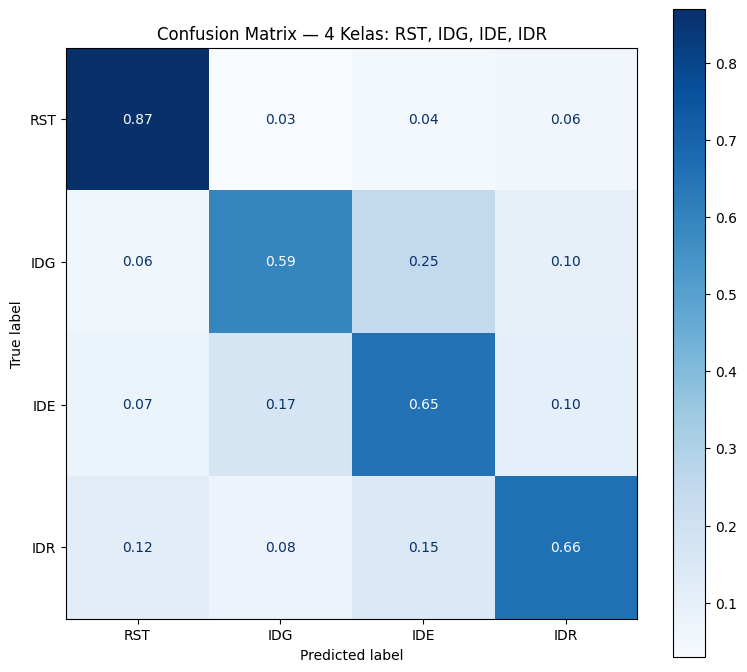

Final CORAL applied: primary -> secondary

MODEL TERSIMPAN:
/content/Creativity-Dataset/output/ensemble_model__merged_4class_fixed.joblib

RESULTS TERSIMPAN:
/content/Creativity-Dataset/output/results_merged_4class_fixed.csv

PREDICTIONS TERSIMPAN:
/content/Creativity-Dataset/output/predictions_merged_4class_fixed.csv

SELESAI.


In [11]:
# ============================================================
# FULL PATCH — MERGED DATASET 4 KELAS: RST, IDG, IDE, IDR
# Tempel sebagai CELL BARU setelah Cell 4.
# Jangan jalankan Cell 5 sampai Cell 10 lama.
# ============================================================

%pip -q install imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import joblib
import warnings

from pathlib import Path
from collections import Counter
from scipy.signal import welch, butter, sosfiltfilt, hilbert
from scipy.stats import entropy

from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedGroupKFold,
    GroupKFold,
    ParameterSampler
)
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)
from imblearn.over_sampling import RandomOverSampler, SMOTE

warnings.filterwarnings("ignore")


# ============================================================
# 1. SETTING UTAMA — SELECTED SUBJECT MODE
# ============================================================

DATASET_MODE = "merged"

LABELS_RAW = ["RST1", "IDG", "IDE", "IDR", "RST2"]
TARGET_LABELS = ["RST", "IDG", "IDE", "IDR"]

# "auto" = kalau subject >=4 pakai group CV, kalau <4 pakai epoch CV
# "group" = subject-wise validation
# "epoch" = window-level validation
CV_MODE = "epoch"

# PENTING:
# False supaya tidak mengambil semua file dari folder.
AUTO_SELECT_ALL_FILES = False

# Safety. Untuk 10 subject normalnya sekitar 110 record.
# 1 subject = 11 record.
MAX_SELECTED_RECORDS_ALLOWED = 130

# Kalau run pertama untuk pilihan 10 subject, pakai True.
# Kalau sudah berhasil dan mau run ulang cepat, ubah False.
FORCE_REBUILD_FEATURES = True

CACHE_VERSION = "run_selected_10subject_4class_v1"

DWT_LEVEL_TARGET = 5
DWT_COEFFS_NAMES = ["A5", "D5", "D4", "D3", "D2", "D1"]

ADD_SPECTRAL_FEATURES = True
ADD_CONNECTIVITY_FEATURES = False
ADD_DERIVED_FEATURES = True
MAX_EPOCHS_PER_SUBJECT_CLASS = 250

N_PARAM_TRIALS = 20
RANDOM_STATE = 42

ALLOW_TEST_SELF_NORMALIZATION = True
APPLY_CORAL = True
CORAL_REG = 1e-4

EXPERIMENT_CONFIGS = [
    {"epoch_seconds": 2.0, "overlap_ratio": 0.75, "primary_trim_seconds": 2.0},
    {"epoch_seconds": 4.0, "overlap_ratio": 0.50, "primary_trim_seconds": 2.0},
]

print("PATCH 4 KELAS AKTIF — SELECTED SUBJECT MODE")
print("Target labels            :", TARGET_LABELS)
print("CV_MODE                  :", CV_MODE)
print("CACHE_VERSION            :", CACHE_VERSION)
print("AUTO_SELECT_ALL_FILES    :", AUTO_SELECT_ALL_FILES)
print("ADD_CONNECTIVITY_FEATURES:", ADD_CONNECTIVITY_FEATURES)
print("N_PARAM_TRIALS           :", N_PARAM_TRIALS)


# ============================================================
# 2. LABEL MAPPING
# ============================================================

def normalize_label(text):
    text = str(text).upper()
    for label in LABELS_RAW:
        if label in text:
            return label
    return None


def remap_to_4class(raw_label):
    if raw_label in ("RST1", "RST2"):
        return "RST"
    if raw_label in ("IDG", "IDE", "IDR"):
        return raw_label
    return None


# ============================================================
# 3. FILE SELECTION — WAJIB PAKAI HASIL PILIHAN CELL SELECTOR
# ============================================================

def prepare_selected_refs_from_previous_cell():
    global refs, refs_df, MANUAL_SELECTED_FILES

    candidate_refs = None

    if "refs" in globals() and isinstance(refs, list) and len(refs) > 0:
        print("Menggunakan refs dari cell selector sebelumnya.")
        candidate_refs = refs

    elif "MANUAL_SELECTED_FILES" in globals() and isinstance(MANUAL_SELECTED_FILES, list) and len(MANUAL_SELECTED_FILES) > 0:
        print("refs belum ada. Membuat refs dari MANUAL_SELECTED_FILES.")
        candidate_refs = discover_selected_refs(MANUAL_SELECTED_FILES)

    else:
        raise ValueError("""
Tidak ada refs dari selector.

Solusi:
1. Jalankan cell file selector.
2. Pilih 10 subject yang ingin dipakai.
3. Klik tombol 'Proses File Terpilih'.
4. Pastikan output selector menampilkan sekitar 110 record untuk 10 subject.
5. Baru jalankan FULL PATCH ini.
""")

    if candidate_refs is None or len(candidate_refs) == 0:
        raise ValueError("Tidak ada record valid dari file yang dipilih.")

    if len(candidate_refs) > MAX_SELECTED_RECORDS_ALLOWED:
        raise ValueError(f"""
Record yang terbaca terlalu banyak: {len(candidate_refs)} record.

Ini berarti FULL PATCH masih menerima semua subject, bukan pilihan 10 subject.

Untuk 10 subject, normalnya sekitar:
10 subject x 11 record = 110 record.

Solusi:
1. Stop cell ini.
2. Jalankan ulang cell file selector.
3. Pilih hanya 10 subject.
4. Klik 'Proses File Terpilih'.
5. Pastikan output selector sekitar 110 record.
6. Jalankan ulang FULL PATCH ini.

Batas safety saat ini: {MAX_SELECTED_RECORDS_ALLOWED} record.
""")

    refs = candidate_refs
    refs_df = pd.DataFrame(refs)

    print("\nJumlah record terdeteksi:", len(refs_df))
    display(refs_df.groupby(["source", "subject_id", "label"]).size().reset_index(name="records"))

    print("Jumlah group/subjek unik:", refs_df["subject_id"].nunique())
    display(refs_df.groupby("source")["subject_id"].nunique().reset_index(name="n_subjects"))

    if "file_path" in refs_df.columns:
        print("\nFile/path yang dipakai:")
        display(refs_df[["source", "subject_id", "label", "file_path"]].drop_duplicates().head(120))

    return refs, refs_df


refs, refs_df = prepare_selected_refs_from_previous_cell()


# ============================================================
# 4. BASIC UTILS
# ============================================================

def epoch_starts(n, sec, overlap, trim):
    size = int(sec * FS_TARGET)
    step = int(size * (1 - overlap))
    trim_size = int(trim * FS_TARGET)

    if step <= 0:
        raise ValueError("Overlap terlalu besar. Step menjadi <= 0.")

    if (n - 2 * trim_size) >= size:
        starts = list(range(trim_size, n - trim_size - size + 1, step))
    else:
        starts = []

    return starts, size


def robust_zscore(v):
    v = np.asarray(v, dtype=float)
    if v.size == 0:
        return v
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    if mad <= 1e-12:
        return np.zeros_like(v)
    return 0.6745 * (v - med) / (mad + 1e-12)


def screen_epoch_starts(eeg, starts, size):
    if not starts:
        return []

    epochs = np.stack([eeg[:, s:s + size] for s in starts])

    ptp = np.max(np.ptp(epochs, axis=2), axis=1)
    grad = np.max(np.mean(np.abs(np.diff(epochs, axis=2)), axis=2), axis=1)

    mask = (
        (np.abs(robust_zscore(np.log10(ptp + 1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD)
        &
        (np.abs(robust_zscore(np.log10(grad + 1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD)
    )

    return [s for s, keep in zip(starts, mask) if keep]


def hjorth_parameters(sig):
    sig = np.asarray(sig, dtype=float)

    activity = np.var(sig)

    if activity <= 1e-18:
        return 0.0, 0.0, 0.0

    d1 = np.diff(sig)
    d2 = np.diff(sig, n=2)

    var_d1 = np.var(d1)
    var_d2 = np.var(d2)

    mobility = np.sqrt(var_d1 / activity)

    if var_d1 <= 1e-18 or mobility <= 1e-18:
        complexity = 0.0
    else:
        complexity = np.sqrt(var_d2 / var_d1) / mobility

    return float(activity), float(mobility), float(complexity)


# ============================================================
# 5. FEATURE EXTRACTION — DWT FIXED LEVEL + SPECTRAL + PLV
# ============================================================

DWT_COLS = [
    f"{ch}__{coeff}__{param}"
    for ch in CANONICAL_CHANNELS
    for coeff in DWT_COEFFS_NAMES
    for param in ["activity", "mobility", "complexity"]
]

FREQUENCY_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}

SPEC_COLS = [
    f"{ch}__spectral__{param}"
    for ch in CANONICAL_CHANNELS
    for param in [*FREQUENCY_BANDS.keys(), "entropy"]
]

CONNECTIVITY_PAIRS = (
    [("F3", "F4"), ("F7", "F8"), ("Fp1", "Fp2")]
    + [("F3", "P3"), ("F4", "P4"), ("F7", "P7"), ("F8", "P8")]
    + [("F3", "O1"), ("F4", "O2")]
    + [("T7", "T8"), ("P7", "P8")]
    + [("C3", "P3"), ("C4", "P4"), ("C3", "C4")]
)

CONNECTIVITY_BANDS = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
}

CONNECTIVITY_COLS = [
    f"plv__{ch1}_{ch2}__{band}"
    for ch1, ch2 in CONNECTIVITY_PAIRS
    for band in CONNECTIVITY_BANDS
]

BASE_FEATURE_COLUMNS = DWT_COLS + (SPEC_COLS if ADD_SPECTRAL_FEATURES else [])
if ADD_CONNECTIVITY_FEATURES:
    BASE_FEATURE_COLUMNS = BASE_FEATURE_COLUMNS + CONNECTIVITY_COLS

print("\nJumlah fitur dasar:")
print("DWT       :", len(DWT_COLS))
print("Spectral  :", len(SPEC_COLS) if ADD_SPECTRAL_FEATURES else 0)
print("PLV       :", len(CONNECTIVITY_COLS) if ADD_CONNECTIVITY_FEATURES else 0)
print("Total base:", len(BASE_FEATURE_COLUMNS))


def extract_dwt_hjorth_features(epoch):
    feats = []

    for sig in epoch:
        sig = np.asarray(sig, dtype=float)

        max_level = pywt.dwt_max_level(len(sig), pywt.Wavelet(WAVELET).dec_len)
        level = min(DWT_LEVEL_TARGET, max_level)

        if level < 1:
            coeff_map = {}
        else:
            coeffs = pywt.wavedec(sig, WAVELET, level=level, mode="periodization")

            coeff_map = {}

            coeff_map[f"A{level}"] = coeffs[0]

            # coeffs[1:] = D_level, D_level-1, ..., D1
            for idx, c in enumerate(coeffs[1:]):
                detail_level = level - idx
                coeff_map[f"D{detail_level}"] = c

        for coeff_name in DWT_COEFFS_NAMES:
            if coeff_name in coeff_map:
                feats.extend(hjorth_parameters(coeff_map[coeff_name]))
            else:
                feats.extend([0.0, 0.0, 0.0])

    return feats


def extract_spectral_features(epoch):
    feats = []
    n_samples = epoch.shape[1]
    nperseg = min(n_samples, 2 * FS_TARGET)

    for sig in epoch:
        f_arr, psd = welch(sig, fs=FS_TARGET, nperseg=nperseg)

        mask_total = (f_arr >= 1.0) & (f_arr < 40.0)
        total_power = np.trapz(psd[mask_total], f_arr[mask_total]) + 1e-12

        for low, high in FREQUENCY_BANDS.values():
            mask_band = (f_arr >= low) & (f_arr < high)
            band_power = np.trapz(psd[mask_band], f_arr[mask_band])
            feats.append(float(band_power / total_power))

        psd_norm = psd / (np.sum(psd) + 1e-12)
        feats.append(float(entropy(psd_norm + 1e-12, base=2)))

    return feats


def compute_plv_band(sig1, sig2, low, high):
    sos = butter(
        4,
        [low, high],
        btype="bandpass",
        fs=FS_TARGET,
        output="sos",
    )

    s1 = sosfiltfilt(sos, sig1.astype(float))
    s2 = sosfiltfilt(sos, sig2.astype(float))

    phi1 = np.angle(hilbert(s1))
    phi2 = np.angle(hilbert(s2))

    return float(np.abs(np.mean(np.exp(1j * (phi1 - phi2)))))


def extract_connectivity_features(epoch):
    ch_idx = {ch: idx for idx, ch in enumerate(CANONICAL_CHANNELS)}
    feats = []

    for ch1, ch2 in CONNECTIVITY_PAIRS:
        if ch1 not in ch_idx or ch2 not in ch_idx:
            feats.extend([0.0] * len(CONNECTIVITY_BANDS))
            continue

        sig1 = epoch[ch_idx[ch1]]
        sig2 = epoch[ch_idx[ch2]]

        for low, high in CONNECTIVITY_BANDS.values():
            feats.append(compute_plv_band(sig1, sig2, low, high))

    return feats


def extract_features(epoch):
    feats = []

    feats.extend(extract_dwt_hjorth_features(epoch))

    if ADD_SPECTRAL_FEATURES:
        feats.extend(extract_spectral_features(epoch))

    if ADD_CONNECTIVITY_FEATURES:
        feats.extend(extract_connectivity_features(epoch))

    return feats


# ============================================================
# 6. FEATURE TABLE
# ============================================================

def config_id(cfg):
    return (
        f"epoch_{cfg['epoch_seconds']}s"
        f"__overlap_{cfg['overlap_ratio']}"
        f"__trim_{cfg['primary_trim_seconds']}s"
        f"__4class"
        f"__{CACHE_VERSION}"
    )


def feature_cache_path(cfg, prepared_records):
    fingerprint = stable_name("|".join(sorted(prepared_records["cache_path"].astype(str))))
    key = f"{DATASET_MODE}__{config_id(cfg)}__{fingerprint}"
    return FEATURE_CACHE_DIR / f"{stable_name(key)}.pkl"


def build_feature_table(prepared_records, config):
    descriptors = []

    for _, record in prepared_records.iterrows():
        eeg = np.load(record["cache_path"], mmap_mode="r")

        trim = (
            config["primary_trim_seconds"]
            if record["source"] == "primary"
            else 0.0
        )

        starts, size = epoch_starts(
            n=record["n_samples"],
            sec=config["epoch_seconds"],
            overlap=config["overlap_ratio"],
            trim=trim,
        )

        raw_label = record["label"]
        target_label = remap_to_4class(raw_label)

        if target_label is None:
            continue

        good_starts = screen_epoch_starts(eeg, starts, size)

        for s in good_starts:
            descriptors.append({
                "source": record["source"],
                "subject_id": record["subject_id"],
                "group_id": f"{record['source']}__{record['subject_id']}",
                "record_id": record["record_id"],
                "label": target_label,
                "raw_label": raw_label,
                "cache_path": record["cache_path"],
                "epoch_start": int(s),
                "epoch_size": int(size),
            })

    if not descriptors:
        raise ValueError("Tidak ada epoch valid. Cek label, durasi epoch, dan preprocessing.")

    desc_df = pd.DataFrame(descriptors)

    # Balance per source-subject-label agar kelas dominan tidak terlalu besar
    balanced_df = pd.concat(
        [
            g.sample(
                n=min(len(g), MAX_EPOCHS_PER_SUBJECT_CLASS),
                random_state=RANDOM_STATE,
            )
            for _, g in desc_df.groupby(["source", "subject_id", "label"], sort=False)
        ],
        ignore_index=True,
    )

    print(f"\nEpochs setelah balancing: {len(balanced_df)}")
    display(balanced_df.groupby(["source", "label"]).size().reset_index(name="epochs"))

    rows = []

    for path, group in balanced_df.groupby("cache_path", sort=False):
        eeg = np.load(path, mmap_mode="r")

        for _, d in group.iterrows():
            start = int(d["epoch_start"])
            size = int(d["epoch_size"])

            epoch = np.asarray(eeg[:, start:start + size], dtype=float)

            feats = extract_features(epoch)

            if len(feats) < len(BASE_FEATURE_COLUMNS):
                feats = feats + [0.0] * (len(BASE_FEATURE_COLUMNS) - len(feats))
            elif len(feats) > len(BASE_FEATURE_COLUMNS):
                feats = feats[:len(BASE_FEATURE_COLUMNS)]

            row = d.drop("cache_path").to_dict()
            row.update(dict(zip(BASE_FEATURE_COLUMNS, feats)))
            rows.append(row)

    feature_df = pd.DataFrame(rows)

    return feature_df


# ============================================================
# 7. DERIVED FEATURES
# ============================================================

ASYM_PAIRS = [
    ("Fp1", "Fp2"),
    ("F3", "F4"),
    ("F7", "F8"),
    ("C3", "C4"),
    ("T7", "T8"),
    ("P7", "P8"),
    ("P3", "P4"),
    ("O1", "O2"),
]

FRONTAL_CH = ["Fp1", "Fp2", "F3", "F4", "F7", "F8"]
PARIETAL_CH = ["P3", "P4", "P7", "P8"]


def add_derived_features(df, eps=1e-9):
    df = df.copy()
    new_cols = []

    # Ratio band per channel
    for ch in CANONICAL_CHANNELS:
        alpha_col = f"{ch}__spectral__alpha"
        theta_col = f"{ch}__spectral__theta"
        beta_col = f"{ch}__spectral__beta"
        gamma_col = f"{ch}__spectral__gamma"

        if alpha_col in df.columns and theta_col in df.columns:
            c = f"{ch}__ratio__alpha_theta"
            df[c] = df[alpha_col] / (df[theta_col] + eps)
            new_cols.append(c)

        if theta_col in df.columns and beta_col in df.columns:
            c = f"{ch}__ratio__theta_beta"
            df[c] = df[theta_col] / (df[beta_col] + eps)
            new_cols.append(c)

        if beta_col in df.columns and gamma_col in df.columns:
            c = f"{ch}__ratio__beta_gamma"
            df[c] = df[beta_col] / (df[gamma_col] + eps)
            new_cols.append(c)

    # Asymmetry kiri-kanan
    for left, right in ASYM_PAIRS:
        for band in ["theta", "alpha", "beta"]:
            left_col = f"{left}__spectral__{band}"
            right_col = f"{right}__spectral__{band}"

            if left_col in df.columns and right_col in df.columns:
                c = f"asym__{left}_{right}__{band}"
                df[c] = (df[right_col] - df[left_col]) / (
                    df[right_col] + df[left_col] + eps
                )
                new_cols.append(c)

    # Frontal-parietal global features
    for band in ["theta", "alpha", "beta"]:
        f_cols = [
            f"{ch}__spectral__{band}"
            for ch in FRONTAL_CH
            if f"{ch}__spectral__{band}" in df.columns
        ]

        p_cols = [
            f"{ch}__spectral__{band}"
            for ch in PARIETAL_CH
            if f"{ch}__spectral__{band}" in df.columns
        ]

        if f_cols and p_cols:
            frontal_mean = df[f_cols].mean(axis=1)
            parietal_mean = df[p_cols].mean(axis=1)

            c1 = f"global__frontal_{band}"
            c2 = f"global__parietal_{band}"
            c3 = f"global__frontal_parietal_{band}_ratio"

            df[c1] = frontal_mean
            df[c2] = parietal_mean
            df[c3] = frontal_mean / (parietal_mean + eps)

            new_cols.extend([c1, c2, c3])

    return df, new_cols


# ============================================================
# 8. NORMALIZATION + CORAL
# ============================================================

def robust_scale_fit(X):
    X = np.asarray(X, dtype=float)

    med = np.median(X, axis=0)
    mad = np.median(np.abs(X - med), axis=0)

    scale = 1.4826 * mad

    zero = scale < 1e-12
    if zero.any():
        std_fallback = X[:, zero].std(axis=0)
        scale[zero] = np.where(std_fallback > 1e-12, std_fallback, 1.0)

    return med, scale


def compute_coral_transform(X_source, X_target, reg=CORAL_REG):
    X_source = np.asarray(X_source, dtype=float)
    X_target = np.asarray(X_target, dtype=float)

    n_source, d = X_source.shape
    n_target = X_target.shape[0]

    min_samples_for_cov = max(10, d // 3)

    mu_source = X_source.mean(axis=0)
    mu_target = X_target.mean(axis=0)

    if n_source < min_samples_for_cov or n_target < min_samples_for_cov:
        return np.eye(d), mu_source, mu_target

    cov_source = np.cov(X_source - mu_source, rowvar=False) + reg * np.eye(d)
    cov_target = np.cov(X_target - mu_target, rowvar=False) + reg * np.eye(d)

    eig_s, vec_s = np.linalg.eigh(cov_source)
    eig_t, vec_t = np.linalg.eigh(cov_target)

    eig_s = np.maximum(eig_s, reg)
    eig_t = np.maximum(eig_t, reg)

    source_inv_sqrt = vec_s @ np.diag(1.0 / np.sqrt(eig_s)) @ vec_s.T
    target_sqrt = vec_t @ np.diag(np.sqrt(eig_t)) @ vec_t.T

    A = source_inv_sqrt @ target_sqrt

    return A, mu_source, mu_target


def apply_coral_transform(X, A, mu_source, mu_target):
    return (X - mu_source) @ A + mu_target


def normalize_per_subject_fold(X_train, groups_train, X_test, groups_test):
    X_train_out = X_train.copy().astype(float)
    X_test_out = X_test.copy().astype(float)

    subject_stats = {}

    # Fit train per subject
    for g in np.unique(groups_train):
        mask = groups_train == g
        med, scale = robust_scale_fit(X_train[mask])
        subject_stats[g] = (med, scale)
        X_train_out[mask] = (X_train[mask] - med) / scale

    # Transform test
    for g in np.unique(groups_test):
        mask = groups_test == g

        if g in subject_stats:
            med, scale = subject_stats[g]
        elif ALLOW_TEST_SELF_NORMALIZATION:
            # Unsupervised: hanya memakai distribusi X_test, tidak memakai label y_test
            med, scale = robust_scale_fit(X_test[mask])
        else:
            med = np.zeros(X_test.shape[1])
            scale = np.ones(X_test.shape[1])

        X_test_out[mask] = (X_test[mask] - med) / scale

    # CORAL primary -> secondary jika train punya dua domain
    if APPLY_CORAL and DATASET_MODE == "merged":
        primary_train = np.array([str(g).startswith("primary__") for g in groups_train])
        secondary_train = np.array([str(g).startswith("secondary__") for g in groups_train])

        if primary_train.sum() > 5 and secondary_train.sum() > 5:
            A, mu_source, mu_target = compute_coral_transform(
                X_train_out[primary_train],
                X_train_out[secondary_train],
            )

            X_train_out[primary_train] = apply_coral_transform(
                X_train_out[primary_train],
                A,
                mu_source,
                mu_target,
            )

            primary_test = np.array([str(g).startswith("primary__") for g in groups_test])

            if primary_test.sum() > 0:
                X_test_out[primary_test] = apply_coral_transform(
                    X_test_out[primary_test],
                    A,
                    mu_source,
                    mu_target,
                )

    return X_train_out, X_test_out


# ============================================================
# 9. CROSS VALIDATION SPLIT
# ============================================================

def cv_splits(y, groups, n_splits=5):
    y = np.asarray(y)
    groups = np.asarray(groups)

    unique_groups = np.unique(groups)
    n_groups = len(unique_groups)

    selected_mode = CV_MODE

    if selected_mode == "auto":
        if n_groups >= 4:
            selected_mode = "group"
        else:
            selected_mode = "epoch"

    if selected_mode == "group":
        actual_splits = min(n_splits, n_groups)

        if actual_splits < 2:
            raise ValueError("Group CV butuh minimal 2 group/subjek.")

        source_labels = np.array([str(g).split("__")[0] for g in groups])
        strata = np.array([f"{src}|{label}" for src, label in zip(source_labels, y)])

        try:
            print(f"CV: StratifiedGroupKFold(k={actual_splits})")
            sgkf = StratifiedGroupKFold(
                n_splits=actual_splits,
                shuffle=True,
                random_state=RANDOM_STATE,
            )

            for train_idx, test_idx in sgkf.split(np.zeros(len(y)), strata, groups=groups):
                yield train_idx, test_idx

        except Exception as e:
            print("StratifiedGroupKFold gagal, fallback GroupKFold:", e)

            gkf = GroupKFold(n_splits=actual_splits)

            for train_idx, test_idx in gkf.split(np.zeros(len(y)), y, groups):
                yield train_idx, test_idx

    elif selected_mode == "epoch":
        print("CV: StratifiedKFold epoch-level. Ini eksploratif, bukan validasi antar-subjek.")

        min_class = min(Counter(y).values())
        actual_splits = min(5, min_class)

        if actual_splits < 2:
            raise ValueError("Data tiap kelas terlalu sedikit untuk StratifiedKFold.")

        skf = StratifiedKFold(
            n_splits=actual_splits,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

        for train_idx, test_idx in skf.split(np.zeros(len(y)), y):
            yield train_idx, test_idx

    else:
        raise ValueError("CV_MODE harus 'auto', 'group', atau 'epoch'.")


# ============================================================
# 10. OVERSAMPLING + MODEL
# ============================================================

def safe_oversample(X_train, y_train, k_neighbors=3):
    counts = Counter(y_train)
    min_count = min(counts.values())

    # Jika kelas sangat kecil, SMOTE tidak aman. Pakai RandomOverSampler.
    if min_count < 4:
        sampler = RandomOverSampler(
            sampling_strategy="not majority",
            random_state=RANDOM_STATE,
        )
        return sampler.fit_resample(X_train, y_train)

    try:
        sampler = SMOTE(
            sampling_strategy="not majority",
            k_neighbors=min(k_neighbors, min_count - 1),
            random_state=RANDOM_STATE,
        )
        return sampler.fit_resample(X_train, y_train)
    except Exception:
        sampler = RandomOverSampler(
            sampling_strategy="not majority",
            random_state=RANDOM_STATE,
        )
        return sampler.fit_resample(X_train, y_train)


def make_model(params, n_features_available):
    select_k = int(min(params["select_k"], n_features_available))

    svm = SVC(
        C=params["svm_C"],
        gamma=params["svm_gamma"],
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )

    rf = RandomForestClassifier(
        n_estimators=params["rf_n"],
        max_depth=params["rf_depth"],
        min_samples_leaf=params["rf_leaf"],
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    et = ExtraTreesClassifier(
        n_estimators=params["et_n"],
        max_depth=params["et_depth"],
        min_samples_leaf=params["et_leaf"],
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    knn = KNeighborsClassifier(
        n_neighbors=params["knn_k"],
        weights=params["knn_weights"],
        metric=params["knn_metric"],
    )

    ensemble = VotingClassifier(
        estimators=[
            ("svm", svm),
            ("rf", rf),
            ("et", et),
            ("knn", knn),
        ],
        voting="soft",
        weights=params["vote_weights"],
        n_jobs=-1,
    )

    pipe = Pipeline([
        ("scaler", RobustScaler()),
        ("select", SelectKBest(score_func=f_classif, k=select_k)),
        ("ensemble", ensemble),
    ])

    return pipe


PARAM_DISTRIBUTIONS = {
    "select_k": [64, 96, 128, 160, 192, 240, 320, 420, 520],
    "svm_C": [0.5, 1, 2, 5, 10, 20],
    "svm_gamma": ["scale", 0.001, 0.003, 0.005, 0.01],
    "rf_n": [200, 300, 500],
    "rf_depth": [None, 10, 20, 30],
    "rf_leaf": [1, 2, 3],
    "et_n": [200, 300, 500],
    "et_depth": [None, 10, 20, 30],
    "et_leaf": [1, 2, 3],
    "knn_k": [3, 5, 7, 9, 11, 15],
    "knn_weights": ["distance", "uniform"],
    "knn_metric": ["minkowski", "manhattan"],
    "vote_weights": [
        [2, 2, 2, 1],
        [2, 3, 3, 1],
        [1, 3, 3, 1],
        [3, 2, 2, 1],
        [1, 2, 3, 1],
    ],
}


def evaluate_params_on_table(df, feature_cols, params):
    X = df[feature_cols].replace([np.inf, -np.inf], 0).fillna(0).values
    y = df["label"].astype(str).values
    groups = df["group_id"].astype(str).values

    scores = []
    all_true = []
    all_pred = []

    for train_idx, test_idx in cv_splits(y, groups, n_splits=5):
        X_train, X_test = normalize_per_subject_fold(
            X[train_idx],
            groups[train_idx],
            X[test_idx],
            groups[test_idx],
        )

        y_train = y[train_idx]
        y_test = y[test_idx]

        X_train_os, y_train_os = safe_oversample(X_train, y_train, k_neighbors=3)

        model = make_model(params, n_features_available=len(feature_cols))
        model.fit(X_train_os, y_train_os)

        pred = model.predict(X_test)

        scores.append(balanced_accuracy_score(y_test, pred))
        all_true.extend(y_test)
        all_pred.extend(pred)

    result = {
        "mean_bal_acc": float(np.mean(scores)),
        "std_bal_acc": float(np.std(scores)),
        "accuracy": float(accuracy_score(all_true, all_pred)),
        "macro_f1": float(f1_score(all_true, all_pred, average="macro", zero_division=0)),
    }

    return result, np.array(all_true), np.array(all_pred)


# ============================================================
# 11. BUILD PREPROCESSED CACHE + FEATURE TABLES
# ============================================================

prepared_records = prepare_preprocessed_cache(refs)

feature_tables = {}

for cfg in EXPERIMENT_CONFIGS:
    ident = config_id(cfg)
    cpath = feature_cache_path(cfg, prepared_records)

    print("\n" + "=" * 80)
    print("BUILD CONFIG:", ident)
    print("=" * 80)

    if cpath.exists() and not FORCE_REBUILD_FEATURES:
        f_df = pd.read_pickle(cpath)
        print("[CACHE] Loaded:", len(f_df), "epochs")
    else:
        f_df = build_feature_table(prepared_records, cfg)

        if ADD_DERIVED_FEATURES:
            f_df, derived_cols = add_derived_features(f_df)
        else:
            derived_cols = []

        f_df.to_pickle(cpath)

    feature_tables[ident] = f_df

    display(f_df.groupby(["source", "label"]).size().reset_index(name="epochs"))


# ============================================================
# 12. TUNING & EVALUASI SEMUA CONFIG
# ============================================================

all_results = []
best_bundle = None

param_candidates = list(ParameterSampler(
    PARAM_DISTRIBUTIONS,
    n_iter=N_PARAM_TRIALS,
    random_state=RANDOM_STATE,
))

print("\nJumlah kandidat parameter:", len(param_candidates))

for ident, df in feature_tables.items():
    print("\n" + "#" * 80)
    print("EVALUASI CONFIG:", ident)
    print("#" * 80)

    meta_cols = {
        "source",
        "subject_id",
        "group_id",
        "record_id",
        "label",
        "raw_label",
        "epoch_start",
        "epoch_size",
    }

    feature_cols = [
        c for c in df.columns
        if c not in meta_cols
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    print("Jumlah fitur:", len(feature_cols))
    print("Distribusi kelas:")
    print(df["label"].value_counts())

    config_best = None

    for i, params in enumerate(param_candidates, 1):
        print(f"  Trial {i:02d}/{len(param_candidates)}", end="")

        try:
            result, y_true, y_pred = evaluate_params_on_table(df, feature_cols, params)
            print(f" | bal_acc={result['mean_bal_acc']:.4f} | macro_f1={result['macro_f1']:.4f}")

            row = {
                "config_id": ident,
                "n_features": len(feature_cols),
                **result,
                "params": params,
            }

            all_results.append(row)

            if config_best is None or row["mean_bal_acc"] > config_best["mean_bal_acc"]:
                config_best = row

            if best_bundle is None or row["mean_bal_acc"] > best_bundle["row"]["mean_bal_acc"]:
                best_bundle = {
                    "row": row,
                    "df": df.copy(),
                    "feature_cols": feature_cols,
                    "y_true": y_true,
                    "y_pred": y_pred,
                }

        except Exception as e:
            print(" | GAGAL:", e)

    print("\nBEST CONFIG SEMENTARA:")
    display(pd.DataFrame([config_best]).drop(columns=["params"]))


results_df = (
    pd.DataFrame(all_results)
    .sort_values("mean_bal_acc", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("TOP 10 HASIL")
print("=" * 80)
display(results_df.drop(columns=["params"]).head(10))

FINAL_CONFIG_ID = best_bundle["row"]["config_id"]
FINAL_PARAMS = best_bundle["row"]["params"]
FINAL_FEATURE_DF = best_bundle["df"].copy()
FINAL_COLS = best_bundle["feature_cols"]

print("\nFINAL CONFIG :", FINAL_CONFIG_ID)
print("FINAL PARAMS :")
print(FINAL_PARAMS)


# ============================================================
# 13. CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

y_true = best_bundle["y_true"]
y_pred = best_bundle["y_pred"]

print("\n" + "=" * 80)
print("FINAL CLASSIFICATION REPORT — 4 KELAS")
print("=" * 80)

print("Accuracy          :", accuracy_score(y_true, y_pred))
print("Balanced Accuracy :", balanced_accuracy_score(y_true, y_pred))
print("Macro F1          :", f1_score(y_true, y_pred, average="macro", zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=TARGET_LABELS,
    zero_division=0,
))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=TARGET_LABELS,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=ax,
)
ax.set_title("Confusion Matrix — 4 Kelas: RST, IDG, IDE, IDR")
plt.tight_layout()
plt.show()


# ============================================================
# 14. FIT FINAL MODEL SEMUA DATA + SAVE MODEL
# ============================================================

X_final = (
    FINAL_FEATURE_DF[FINAL_COLS]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
    .values
)

y_final = FINAL_FEATURE_DF["label"].astype(str).values
groups_final = FINAL_FEATURE_DF["group_id"].astype(str).values

# Normalize per subject untuk final model
X_final_norm = X_final.copy().astype(float)
final_subject_stats = {}

for g in np.unique(groups_final):
    mask = groups_final == g
    med, scale = robust_scale_fit(X_final[mask])
    final_subject_stats[g] = (med, scale)
    X_final_norm[mask] = (X_final[mask] - med) / scale

# CORAL final primary -> secondary
final_coral_params = None

if APPLY_CORAL and DATASET_MODE == "merged":
    primary_mask = np.array([str(g).startswith("primary__") for g in groups_final])
    secondary_mask = np.array([str(g).startswith("secondary__") for g in groups_final])

    if primary_mask.sum() > 5 and secondary_mask.sum() > 5:
        A, mu_source, mu_target = compute_coral_transform(
            X_final_norm[primary_mask],
            X_final_norm[secondary_mask],
        )

        X_final_norm[primary_mask] = apply_coral_transform(
            X_final_norm[primary_mask],
            A,
            mu_source,
            mu_target,
        )

        final_coral_params = {
            "A": A,
            "mu_source": mu_source,
            "mu_target": mu_target,
        }

        print("Final CORAL applied: primary -> secondary")

# Oversample final training
X_final_os, y_final_os = safe_oversample(X_final_norm, y_final, k_neighbors=3)

final_model = make_model(
    FINAL_PARAMS,
    n_features_available=len(FINAL_COLS),
)

final_model.fit(X_final_os, y_final_os)

model_bundle = {
    "model": final_model,
    "dataset_mode": DATASET_MODE,
    "target_labels": TARGET_LABELS,
    "final_config_id": FINAL_CONFIG_ID,
    "final_params": FINAL_PARAMS,
    "feature_columns": FINAL_COLS,
    "channels": CANONICAL_CHANNELS,
    "sampling_rate": FS_TARGET,
    "wavelet": WAVELET,
    "dwt_level_target": DWT_LEVEL_TARGET,
    "dwt_coeff_names": DWT_COEFFS_NAMES,
    "add_spectral_features": ADD_SPECTRAL_FEATURES,
    "add_connectivity_features": ADD_CONNECTIVITY_FEATURES,
    "add_derived_features": ADD_DERIVED_FEATURES,
    "subject_stats": final_subject_stats,
    "coral_params": final_coral_params,
    "apply_coral": APPLY_CORAL,
    "cv_mode": CV_MODE,
}

model_path = OUTPUT_DIR / "ensemble_model__merged_4class_fixed.joblib"
joblib.dump(model_bundle, model_path)

results_path = OUTPUT_DIR / "results_merged_4class_fixed.csv"
results_df.to_csv(results_path, index=False)

pred_path = OUTPUT_DIR / "predictions_merged_4class_fixed.csv"
pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred,
}).to_csv(pred_path, index=False)

print("\nMODEL TERSIMPAN:")
print(model_path)

print("\nRESULTS TERSIMPAN:")
print(results_path)

print("\nPREDICTIONS TERSIMPAN:")
print(pred_path)

print("\nSELESAI.")

BOOST MODE: epoch
Feature table: epoch_4.0s__overlap_0.5__trim_2.0s__4class__run_selected_10subject_4class_v1
Jumlah epoch : 4027
Distribusi label:
label
RST    1469
IDE    1184
IDG     898
IDR     476
Name: count, dtype: int64
Jumlah fitur awal: 465

BOOST TRIAL 1/15 | svm_rbf | k=120
CV: StratifiedKFold epoch-level
Balanced Accuracy: 0.6484792804112731
Accuracy         : 0.7116960516513534
Macro F1         : 0.6592564736583632

BOOST TRIAL 2/15 | svm_rbf | k=160
CV: StratifiedKFold epoch-level
Balanced Accuracy: 0.6550501546884533
Accuracy         : 0.7216290042215049
Macro F1         : 0.6665633450799814

BOOST TRIAL 3/15 | svm_rbf | k=240
CV: StratifiedKFold epoch-level
Balanced Accuracy: 0.6809081220449029
Accuracy         : 0.7432331760615843
Macro F1         : 0.6950097461035276

BOOST TRIAL 4/15 | svm_rbf_c50 | k=160
CV: StratifiedKFold epoch-level
Balanced Accuracy: 0.6546673331389048
Accuracy         : 0.7208840327787435
Macro F1         : 0.6660855956801651

BOOST TRIAL 5/15

,model_name,k_features,mean_bal_acc,std_bal_acc,accuracy,macro_f1
0,svm_rbf_c50,240,0.680909,0.010630,0.743233,0.694979
1,svm_rbf,240,0.680908,0.009672,0.743233,0.695010
2,svm_rbf_c100,240,0.680698,0.010615,0.742985,0.694738
3,svm_pca,240,0.655942,0.023369,0.715421,0.669143
4,svm_pca,160,0.655942,0.023369,0.715421,0.669143
5,svm_rbf,160,0.655050,0.011894,0.721629,0.666563
6,svm_rbf_c50,160,0.654667,0.012354,0.720884,0.666086
7,svm_rbf_c100,160,0.654458,0.013087,0.720636,0.665876
8,svm_rbf,120,0.648479,0.016809,0.711696,0.659256
9,hard_vote,240,0.623540,0.020243,0.700273,0.645658



BEST BOOSTER REPORT
Best model        : svm_rbf_c50
Best k_features   : 240
Accuracy          : 0.7432331760615843
Balanced Accuracy : 0.6809041041796096
Macro F1          : 0.6949785133077746

Classification Report:
              precision    recall  f1-score   support

         RST       0.79      0.95      0.86      1469
         IDG       0.75      0.62      0.68       898
         IDE       0.69      0.70      0.69      1184
         IDR       0.68      0.46      0.54       476

    accuracy                           0.74      4027
   macro avg       0.73      0.68      0.69      4027
weighted avg       0.74      0.74      0.73      4027



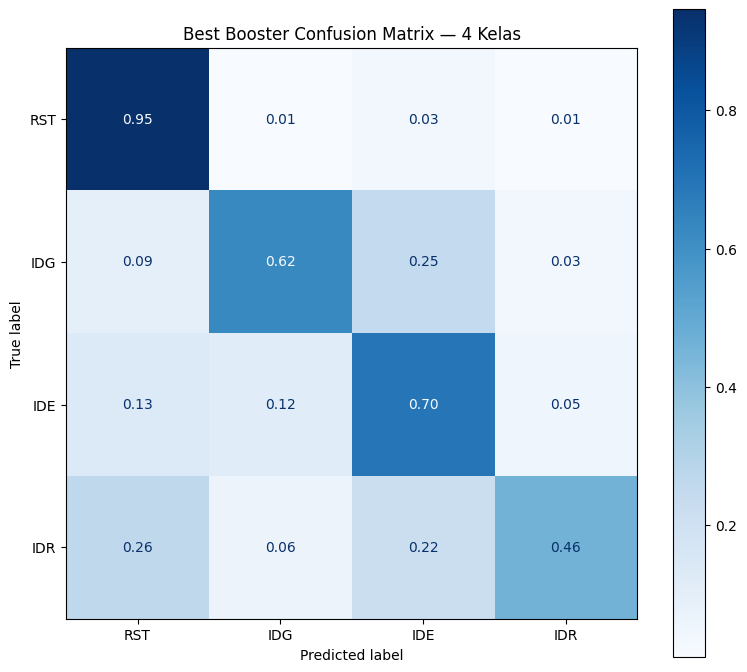


BOOST RESULTS TERSIMPAN:
/content/Creativity-Dataset/output/boost_results_high_accuracy_4class_fixed.csv

BOOST PREDICTIONS TERSIMPAN:
/content/Creativity-Dataset/output/boost_predictions_high_accuracy_4class_fixed.csv


In [13]:
# ============================================================
# HIGH ACCURACY BOOSTER FIXED — TANPA MLP ERROR
# Jalankan setelah FULL PATCH selesai
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE

BOOST_MODE = "epoch"
BOOST_N_SPLITS = 5
BOOST_RANDOM_STATE = 42
BOOST_USE_OVERSAMPLE = True

print("BOOST MODE:", BOOST_MODE)

if "feature_tables" not in globals() or len(feature_tables) == 0:
    raise ValueError("feature_tables belum ada. Jalankan FULL PATCH dulu sampai selesai.")

boost_ident = list(feature_tables.keys())[-1]
boost_df = feature_tables[boost_ident].copy()

print("Feature table:", boost_ident)
print("Jumlah epoch :", len(boost_df))
print("Distribusi label:")
print(boost_df["label"].value_counts())

meta_cols = {"source", "subject_id", "group_id", "record_id", "label", "raw_label", "epoch_start", "epoch_size"}

feature_cols = [
    c for c in boost_df.columns
    if c not in meta_cols and pd.api.types.is_numeric_dtype(boost_df[c])
]

print("Jumlah fitur awal:", len(feature_cols))

X_all = boost_df[feature_cols].replace([np.inf, -np.inf], 0).fillna(0).values
y_all = boost_df["label"].astype(str).values
groups_all = boost_df["group_id"].astype(str).values
records_all = boost_df["record_id"].astype(str).values


def make_boost_splits(y, groups, records, mode="epoch", n_splits=5):
    y = np.asarray(y)
    groups = np.asarray(groups)
    records = np.asarray(records)

    if mode == "epoch":
        print("CV: StratifiedKFold epoch-level")
        min_class = min(Counter(y).values())
        actual_splits = min(n_splits, min_class)
        skf = StratifiedKFold(n_splits=actual_splits, shuffle=True, random_state=BOOST_RANDOM_STATE)

        for train_idx, test_idx in skf.split(np.zeros(len(y)), y):
            yield train_idx, test_idx

    elif mode == "record":
        print("CV: GroupKFold by record_id")
        unique_records = np.unique(records)
        actual_splits = min(n_splits, len(unique_records))
        gkf = GroupKFold(n_splits=actual_splits)

        for train_idx, test_idx in gkf.split(np.zeros(len(y)), y, groups=records):
            yield train_idx, test_idx

    elif mode == "group":
        print("CV: GroupKFold by subject")
        unique_groups = np.unique(groups)
        actual_splits = min(n_splits, len(unique_groups))
        gkf = GroupKFold(n_splits=actual_splits)

        for train_idx, test_idx in gkf.split(np.zeros(len(y)), y, groups=groups):
            yield train_idx, test_idx

    else:
        raise ValueError("BOOST_MODE harus 'epoch', 'record', atau 'group'.")


def boost_oversample(X_train, y_train):
    if not BOOST_USE_OVERSAMPLE:
        return X_train, y_train

    counts = Counter(y_train)
    min_count = min(counts.values())

    if min_count < 4:
        sampler = RandomOverSampler(sampling_strategy="not majority", random_state=BOOST_RANDOM_STATE)
        return sampler.fit_resample(X_train, y_train)

    try:
        sampler = SMOTE(
            sampling_strategy="not majority",
            k_neighbors=min(3, min_count - 1),
            random_state=BOOST_RANDOM_STATE
        )
        return sampler.fit_resample(X_train, y_train)

    except Exception:
        sampler = RandomOverSampler(sampling_strategy="not majority", random_state=BOOST_RANDOM_STATE)
        return sampler.fit_resample(X_train, y_train)


def make_boost_model(model_name, k_features):
    if model_name == "extra_trees_1000":
        clf = ExtraTreesClassifier(
            n_estimators=1000,
            max_depth=None,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=BOOST_RANDOM_STATE,
            n_jobs=-1
        )

        pipe = Pipeline([
            ("scaler", RobustScaler()),
            ("select", SelectKBest(score_func=f_classif, k=k_features)),
            ("clf", clf)
        ])

    elif model_name == "extra_trees_mi":
        clf = ExtraTreesClassifier(
            n_estimators=1000,
            max_depth=None,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=BOOST_RANDOM_STATE,
            n_jobs=-1
        )

        pipe = Pipeline([
            ("scaler", RobustScaler()),
            ("select", SelectKBest(score_func=mutual_info_classif, k=k_features)),
            ("clf", clf)
        ])

    elif model_name == "random_forest":
        clf = RandomForestClassifier(
            n_estimators=800,
            max_depth=30,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            random_state=BOOST_RANDOM_STATE,
            n_jobs=-1
        )

        pipe = Pipeline([
            ("scaler", RobustScaler()),
            ("select", SelectKBest(score_func=f_classif, k=k_features)),
            ("clf", clf)
        ])

    elif model_name == "svm_rbf":
        clf = SVC(
            C=30,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=BOOST_RANDOM_STATE
        )

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=k_features)),
            ("clf", clf)
        ])

    elif model_name == "svm_rbf_c50":
        clf = SVC(
            C=50,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=BOOST_RANDOM_STATE
        )

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=k_features)),
            ("clf", clf)
        ])

    elif model_name == "svm_rbf_c100":
        clf = SVC(
            C=100,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=BOOST_RANDOM_STATE
        )

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=k_features)),
            ("clf", clf)
        ])

    elif model_name == "svm_pca":
        clf = SVC(
            C=50,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=BOOST_RANDOM_STATE
        )

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=min(100, k_features), random_state=BOOST_RANDOM_STATE)),
            ("clf", clf)
        ])

    elif model_name == "knn_best":
        clf = KNeighborsClassifier(
            n_neighbors=3,
            weights="distance",
            metric="manhattan",
            n_jobs=-1
        )

        pipe = Pipeline([
            ("scaler", RobustScaler()),
            ("select", SelectKBest(score_func=f_classif, k=k_features)),
            ("clf", clf)
        ])

    elif model_name == "hard_vote":
        et = ExtraTreesClassifier(
            n_estimators=1000,
            max_depth=None,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=BOOST_RANDOM_STATE,
            n_jobs=-1
        )

        rf = RandomForestClassifier(
            n_estimators=800,
            max_depth=30,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            random_state=BOOST_RANDOM_STATE,
            n_jobs=-1
        )

        svm = SVC(
            C=50,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=BOOST_RANDOM_STATE
        )

        knn = KNeighborsClassifier(
            n_neighbors=3,
            weights="distance",
            metric="manhattan",
            n_jobs=-1
        )

        clf = VotingClassifier(
            estimators=[("et", et), ("rf", rf), ("svm", svm), ("knn", knn)],
            voting="hard",
            weights=[4, 3, 4, 1],
            n_jobs=-1
        )

        pipe = Pipeline([
            ("scaler", RobustScaler()),
            ("select", SelectKBest(score_func=f_classif, k=k_features)),
            ("clf", clf)
        ])

    else:
        raise ValueError("Model tidak dikenal:", model_name)

    return pipe


BOOST_CANDIDATES = [
    {"model_name": "svm_rbf", "k_features": 120},
    {"model_name": "svm_rbf", "k_features": 160},
    {"model_name": "svm_rbf", "k_features": 240},
    {"model_name": "svm_rbf_c50", "k_features": 160},
    {"model_name": "svm_rbf_c50", "k_features": 240},
    {"model_name": "svm_rbf_c100", "k_features": 160},
    {"model_name": "svm_rbf_c100", "k_features": 240},
    {"model_name": "svm_pca", "k_features": 160},
    {"model_name": "svm_pca", "k_features": 240},
    {"model_name": "extra_trees_1000", "k_features": 240},
    {"model_name": "extra_trees_1000", "k_features": 360},
    {"model_name": "extra_trees_mi", "k_features": 240},
    {"model_name": "random_forest", "k_features": 240},
    {"model_name": "hard_vote", "k_features": 160},
    {"model_name": "hard_vote", "k_features": 240},
]


boost_results = []
best_boost = None

for i, cfg in enumerate(BOOST_CANDIDATES, 1):
    model_name = cfg["model_name"]
    k_features = min(cfg["k_features"], len(feature_cols))

    print("\n" + "=" * 80)
    print(f"BOOST TRIAL {i}/{len(BOOST_CANDIDATES)} | {model_name} | k={k_features}")
    print("=" * 80)

    fold_scores = []
    all_true = []
    all_pred = []

    try:
        for train_idx, test_idx in make_boost_splits(y_all, groups_all, records_all, mode=BOOST_MODE, n_splits=BOOST_N_SPLITS):
            X_train, X_test = normalize_per_subject_fold(
                X_all[train_idx],
                groups_all[train_idx],
                X_all[test_idx],
                groups_all[test_idx]
            )

            y_train = y_all[train_idx]
            y_test = y_all[test_idx]

            X_train_res, y_train_res = boost_oversample(X_train, y_train)

            model = make_boost_model(model_name, k_features)
            model.fit(X_train_res, y_train_res)

            pred = model.predict(X_test)

            fold_scores.append(balanced_accuracy_score(y_test, pred))
            all_true.extend(y_test)
            all_pred.extend(pred)

        row = {
            "model_name": model_name,
            "k_features": k_features,
            "mean_bal_acc": float(np.mean(fold_scores)),
            "std_bal_acc": float(np.std(fold_scores)),
            "accuracy": float(accuracy_score(all_true, all_pred)),
            "macro_f1": float(f1_score(all_true, all_pred, average="macro", zero_division=0))
        }

        boost_results.append(row)

        print("Balanced Accuracy:", row["mean_bal_acc"])
        print("Accuracy         :", row["accuracy"])
        print("Macro F1         :", row["macro_f1"])

        if best_boost is None or row["mean_bal_acc"] > best_boost["row"]["mean_bal_acc"]:
            best_boost = {
                "row": row,
                "model_name": model_name,
                "k_features": k_features,
                "y_true": np.array(all_true),
                "y_pred": np.array(all_pred)
            }

    except Exception as e:
        print("SKIP karena error:", e)


if len(boost_results) == 0:
    raise ValueError("Semua booster gagal. Cek data atau feature table.")

boost_results_df = pd.DataFrame(boost_results).sort_values("mean_bal_acc", ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("TOP BOOST RESULTS")
print("=" * 80)
display(boost_results_df)

best_y_true = best_boost["y_true"]
best_y_pred = best_boost["y_pred"]

print("\n" + "=" * 80)
print("BEST BOOSTER REPORT")
print("=" * 80)

print("Best model        :", best_boost["model_name"])
print("Best k_features   :", best_boost["k_features"])
print("Accuracy          :", accuracy_score(best_y_true, best_y_pred))
print("Balanced Accuracy :", balanced_accuracy_score(best_y_true, best_y_pred))
print("Macro F1          :", f1_score(best_y_true, best_y_pred, average="macro", zero_division=0))

print("\nClassification Report:")
print(classification_report(best_y_true, best_y_pred, labels=TARGET_LABELS, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    best_y_true,
    best_y_pred,
    labels=TARGET_LABELS,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=ax
)

ax.set_title("Best Booster Confusion Matrix — 4 Kelas")
plt.tight_layout()
plt.show()

boost_results_path = OUTPUT_DIR / "boost_results_high_accuracy_4class_fixed.csv"
boost_pred_path = OUTPUT_DIR / "boost_predictions_high_accuracy_4class_fixed.csv"

boost_results_df.to_csv(boost_results_path, index=False)
pd.DataFrame({"y_true": best_y_true, "y_pred": best_y_pred}).to_csv(boost_pred_path, index=False)

print("\nBOOST RESULTS TERSIMPAN:")
print(boost_results_path)

print("\nBOOST PREDICTIONS TERSIMPAN:")
print(boost_pred_path)